# AdventureWorks — Profitability & Margin Analysis

**Part 2 of the project.** The forecasting notebook (`sales_forecasting_simulation.ipynb`)
answered *how much will we sell*. This notebook asks the questions a business-analysis /
FP&A team asks next: **how much do we actually earn, where, why is it changing, and what
should change?**

It uses the cost fields of the same dataset (`Total Product Cost`, `Standard Cost`,
`List Price`), which the forecasting work did not need:

1. **Margin matrix** — which channel × category combinations make or lose money
2. **Growth without profit** — reseller revenue rises while its gross profit turns negative
3. **Gross-profit bridge** — the change decomposed exactly into volume, discount depth and product mix
4. **Root cause 1** — one uniform reseller discount applied to models with very different cost structures
5. **Root cause 2** — extra discounts on top of the standard reseller price
6. **Action scenarios** — what a reseller price floor is worth, what it costs in revenue, and an
   initiative bridge that splits it into three steps with an execution order and KPI targets
7. **Next-year operating simulation** — growth, mix and execution uncertainty combined; status quo vs initiatives
8. **Findings → actions**, with the questions finance cannot answer alone

*Scope*: gross profit at standard cost. The dataset has no operating expenses, freight,
inventory or receivables, so nothing below gross profit is analysed. All figures come from
Microsoft's AdventureWorks sample data and are illustrative, not industry benchmarks.

## 0. Setup, data loading and validation

Four checks decide how margins can be analysed:

- `Total Product Cost` = quantity × `Product Standard Cost` on every line, and every product
  has **one** standard cost for the whole history. A change in average cost-to-list ratio
  is therefore **pure product mix**, never a cost increase — this makes the bridge in
  Section 3 exact and easy to read.
- `Unit Price Discount Pct` is zero on every line: discounts are **embedded in the unit
  price**, so they are measured here as *realised price ÷ list price*.
- `Sales Amount` is below `Extended Amount` on 3,282 reseller lines — an extra line-level
  discount. `Sales Amount` is used as revenue throughout.
- **Gross profit** = `Sales Amount` − `Total Product Cost`.

Comparison windows match the forecast base of Part 1: **LTM** (last twelve months,
2019-06-17 … 2020-06-15, 365 days) versus the **prior** 365 days. Fiscal years (July–June)
are shown for trend only; FY2020 is missing its final 15 days.

In [1]:
# === 0. Setup, data loading and validation ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 160)
BLUE, RED, GREY, GREEN = "#4878a8", "#c0504d", "#9a9a9a", "#5b9e6f"
musd = FuncFormatter(lambda v, _: f"{'-' if v < 0 else ''}${abs(v):,.1f}M")

# works from notebooks/ (repo layout) or from a folder holding the workbook
XLSX = next(p for p in ["../data/AdventureWorks_Sales.xlsx", "data/AdventureWorks_Sales.xlsx",
                        "AdventureWorks Sales.xlsx"] if Path(p).exists())
FIG_DIR = Path("../figures") if Path("../figures").is_dir() else None   # export charts in repo layout

wb = pd.read_excel(XLSX, sheet_name=None)
s = (wb["Sales_data"]
     .merge(wb["Sales Order_data"][["SalesOrderLineKey", "Channel"]], on="SalesOrderLineKey")
     .merge(wb["Product_data"], on="ProductKey"))
s["date"] = pd.to_datetime(s["OrderDateKey"], format="%Y%m%d")
s["FY"] = s["date"].dt.year + (s["date"].dt.month >= 7)          # fiscal year July..June
s["GP"] = s["Sales Amount"] - s["Total Product Cost"]           # gross profit at standard cost
s["L"] = s["Order Quantity"] * s["List Price"]                  # value at list price

# --- validation ---
assert np.allclose(s["Total Product Cost"], s["Order Quantity"] * s["Product Standard Cost"])
assert s.groupby("ProductKey")["Product Standard Cost"].nunique().max() == 1   # one cost per product
assert (s["Unit Price Discount Pct"] == 0).all()                               # discounts sit in price
extra = (s["Extended Amount"] - s["Sales Amount"]) > 0.01
print(f"order lines            : {len(s):,}")
print(f"revenue / gross profit : ${s['Sales Amount'].sum()/1e6:,.1f}M / ${s['GP'].sum()/1e6:,.1f}M "
      f"(GM {s['GP'].sum()/s['Sales Amount'].sum():.1%})")
print(f"lines with extra discount (Sales < Extended): {extra.sum():,}, all {s.loc[extra,'Channel'].unique()}")
print(f"realised price / list  : " + ", ".join(
    f"{c} {g['Sales Amount'].sum()/g['L'].sum():.3f}" for c, g in s.groupby("Channel")))

# comparison windows: LTM = forecast base of Part 1, prior = the 365 days before
end = s["date"].max()
s["period"] = np.select([s["date"] > end - pd.Timedelta(days=365),
                         s["date"] > end - pd.Timedelta(days=730)], ["LTM", "prior"], None)
ltm, prior = s[s["period"] == "LTM"], s[s["period"] == "prior"]
print(f"LTM   : {ltm['date'].min().date()} .. {ltm['date'].max().date()}  revenue ${ltm['Sales Amount'].sum()/1e6:,.2f}M")
print(f"prior : {prior['date'].min().date()} .. {prior['date'].max().date()}  revenue ${prior['Sales Amount'].sum()/1e6:,.2f}M")

def savefig(name):
    if FIG_DIR is not None:
        plt.savefig(FIG_DIR / name, dpi=110, bbox_inches="tight")

order lines            : 121,253
revenue / gross profit : $109.8M / $12.6M (GM 11.4%)
lines with extra discount (Sales < Extended): 3,282, all ['Reseller']
realised price / list  : Internet 1.000, Reseller 0.585
LTM   : 2019-06-17 .. 2020-06-15  revenue $53.02M
prior : 2018-06-17 .. 2019-06-16  revenue $33.58M


## 1. Where the profit is made — channel × category margin matrix (LTM)

The first question in any margin review: which parts of the business generate the gross
profit, and which only generate revenue.

                      revenue     GP  rev share  GP share     GM
Channel  Category                                               
Internet Accessories    0.693  0.434      0.013     0.072  0.626
         Bikes         15.004  6.073      0.283     1.010  0.405
         Clothing       0.336  0.135      0.006     0.022  0.402
Reseller Accessories    0.414  0.146      0.008     0.024  0.352
         Bikes         29.430 -1.217      0.555    -0.202 -0.041
         Clothing       0.983  0.066      0.019     0.011  0.067
         Components     6.164  0.376      0.116     0.062  0.061

by channel (LTM, $M):
          revenue     GP     GM
Channel                        
Internet   16.033  6.642  0.414
Reseller   36.992 -0.630 -0.017


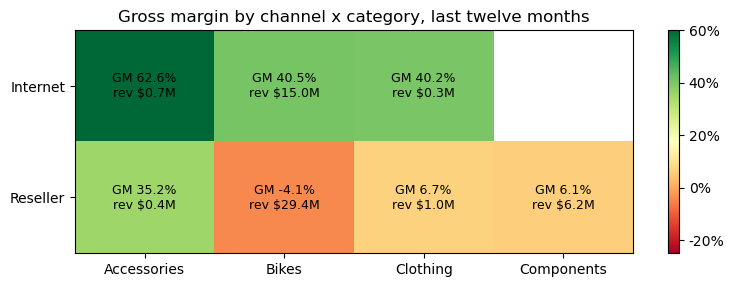

In [2]:
# === 1. Margin matrix, LTM ===
mx = ltm.groupby(["Channel", "Category"]).agg(revenue=("Sales Amount", "sum"), GP=("GP", "sum"))
mx["rev share"] = mx["revenue"] / mx["revenue"].sum()
mx["GP share"] = mx["GP"] / mx["GP"].sum()
mx["GM"] = mx["GP"] / mx["revenue"]
show = mx.copy(); show[["revenue", "GP"]] /= 1e6
print(show.round(3).to_string(float_format=lambda v: f"{v:,.3f}"))

ch = ltm.groupby("Channel").agg(revenue=("Sales Amount", "sum"), GP=("GP", "sum"))
ch["GM"] = ch["GP"] / ch["revenue"]
print("\nby channel (LTM, $M):")
print((ch / [1e6, 1e6, 1]).round(3))

# heatmap: gross margin, annotated with revenue
gm = mx["GM"].unstack(); rev = mx["revenue"].unstack() / 1e6
fig, ax = plt.subplots(figsize=(9, 2.9))
im = ax.imshow(gm.values, cmap="RdYlGn", vmin=-0.25, vmax=0.6, aspect="auto")
ax.set_xticks(range(gm.shape[1]), gm.columns); ax.set_yticks(range(gm.shape[0]), gm.index)
for i in range(gm.shape[0]):
    for j in range(gm.shape[1]):
        if not np.isnan(gm.values[i, j]):
            ax.text(j, i, f"GM {gm.values[i, j]:.1%}\nrev ${rev.values[i, j]:,.1f}M",
                    ha="center", va="center", fontsize=9)
ax.set_title("Gross margin by channel x category, last twelve months")
plt.colorbar(im, ax=ax, format=FuncFormatter(lambda v, _: f"{v:.0%}"))
savefig("10_margin_matrix.png"); plt.show()

**Reading the matrix.** The two channels are two different businesses:

- **Internet** sells at list price: ~30% of LTM revenue, **41% gross margin**, and it earns
  more than the whole company's gross profit on its own.
- **Reseller** sells at a standard 40% discount: ~70% of revenue at a **negative** gross
  margin. Reseller *Bikes* — the single largest cell, $29M — loses $1.2M.

So the company's gross profit is generated by less than a third of its revenue. That is
not visible in a revenue-only forecast — and it changes what "growth" is worth.

## 2. Growth without profit — the reseller channel over time

by fiscal year ($M; FY2020 lacks its final 15 days):
         revenue                GP                GM         
Channel Internet Reseller Internet Reseller Internet Reseller
FY                                                           
2018       7.572   16.288    3.045   -0.009    0.402   -0.001
2019       6.148   27.922    2.555    1.153    0.415    0.041
2020      15.638   36.240    6.481   -0.674    0.414   -0.019

LTM vs prior 365 days ($M):
         revenue           GP      
period       LTM  prior   LTM prior
Channel                            
Internet   16.03   5.97  6.64  2.48
Reseller   36.99  27.61 -0.63  0.76

reseller revenue +34.0%, reseller GP $+0.76M -> $-0.63M


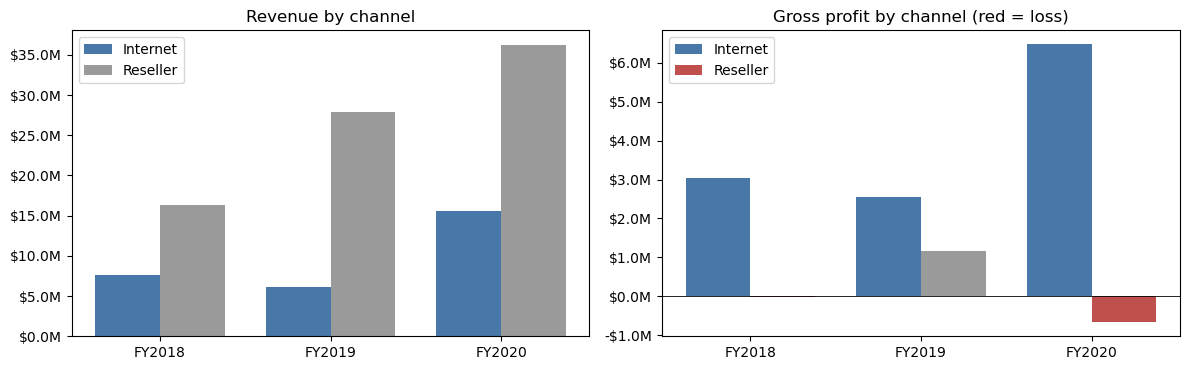

In [3]:
# === 2. Trend by fiscal year and LTM vs prior ===
fy = s.groupby(["FY", "Channel"]).agg(revenue=("Sales Amount", "sum"), GP=("GP", "sum"))
fy["GM"] = fy["GP"] / fy["revenue"]
print("by fiscal year ($M; FY2020 lacks its final 15 days):")
print((fy / [1e6, 1e6, 1]).round(3).unstack("Channel"))

cmp_ = s[s["period"].notna()].groupby(["Channel", "period"]).agg(
    revenue=("Sales Amount", "sum"), GP=("GP", "sum")).unstack("period")
print("\nLTM vs prior 365 days ($M):")
print((cmp_ / 1e6).round(2))
r_rev = cmp_.loc["Reseller", ("revenue", "LTM")] / cmp_.loc["Reseller", ("revenue", "prior")] - 1
print(f"\nreseller revenue {r_rev:+.1%}, reseller GP "
      f"${cmp_.loc['Reseller', ('GP', 'prior')]/1e6:+.2f}M -> ${cmp_.loc['Reseller', ('GP', 'LTM')]/1e6:+.2f}M")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
w = 0.38; yrs = sorted(s["FY"].unique()); xs = np.arange(len(yrs))
for k, (c, col) in enumerate([("Internet", BLUE), ("Reseller", GREY)]):
    sub = fy.xs(c, level="Channel")
    axes[0].bar(xs + (k - .5) * w, sub["revenue"] / 1e6, w, color=col, label=c)
    axes[1].bar(xs + (k - .5) * w, sub["GP"] / 1e6, w, color=[RED if v < 0 else col for v in sub["GP"]], label=c)
for ax, t in zip(axes, ["Revenue by channel", "Gross profit by channel (red = loss)"]):
    ax.set_xticks(xs, [f"FY{y}" for y in yrs]); ax.yaxis.set_major_formatter(musd)
    ax.set_title(t); ax.legend(); ax.axhline(0, color="k", lw=0.6)
plt.tight_layout(); savefig("11_growth_without_profit.png"); plt.show()

**Reseller: more revenue, less profit.** Reseller revenue grows every year (+34% LTM vs the
prior 365 days), yet its gross profit goes from **+$0.76M to −$0.63M**. Internet revenue
almost triples at a stable ~41% margin, which is why *company* gross profit still rises.
A plan that targets revenue growth without separating the channels would reward exactly
the growth that is destroying margin.

## 3. Gross-profit bridge — why did gross profit change?

A bridge (the same technique as a budget-versus-actual variance analysis) splits a change
into causes that different owners control. Writing a channel's gross profit as

$$GP = L \times (r - c)$$

with $L$ = sales volume valued at list price, $r$ = realised price ÷ list (discount depth)
and $c$ = standard cost ÷ list, the change from prior to LTM splits **exactly** into:

| Effect | Formula | Business owner |
|---|---|---|
| Volume | $(L_1 - L_0) \times (r_0 - c_0)$ | Sales — selling more at last year's economics |
| Discount depth | $L_1 \times (r_1 - r_0)$ | Pricing / sales — giving deeper discounts |
| Product mix | $-L_1 \times (c_1 - c_0)$ | Product / sales — selling higher-cost-ratio products |

Because each product has a single standard cost and list price (Section 0), $c$ moves
**only** when the product mix moves — there is no hidden cost-inflation term.

Internet  start +2.48M  volume +4.18M  discount +0.00M  mix -0.02M  end +6.64M   | r 1.000->1.000, c 0.584->0.586
Reseller  start +0.76M  volume +0.27M  discount -0.33M  mix -1.33M  end -0.63M   | r 0.588->0.582, c 0.571->0.592

company GP: $3.24M -> $6.01M


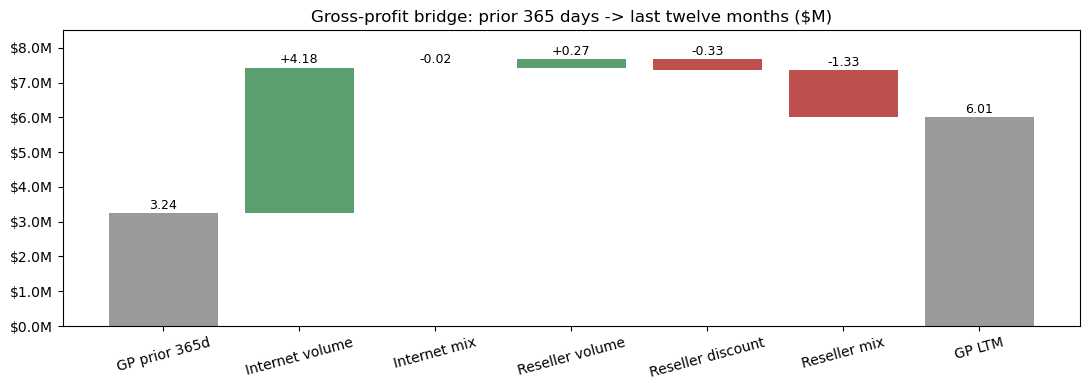

In [4]:
# === 3. Gross-profit bridge, prior 365 days -> LTM ===
def bridge(d0, d1):
    L0, L1 = d0["L"].sum(), d1["L"].sum()
    r0, r1 = d0["Sales Amount"].sum() / L0, d1["Sales Amount"].sum() / L1
    c0, c1 = d0["Total Product Cost"].sum() / L0, d1["Total Product Cost"].sum() / L1
    out = {"start": d0["GP"].sum(), "volume": (L1 - L0) * (r0 - c0),
           "discount": L1 * (r1 - r0), "mix": -L1 * (c1 - c0), "end": d1["GP"].sum()}
    assert np.isclose(out["start"] + out["volume"] + out["discount"] + out["mix"], out["end"])
    return out, dict(L0=L0, L1=L1, r0=r0, r1=r1, c0=c0, c1=c1)

br = {}
for c in ["Internet", "Reseller"]:
    br[c], k = bridge(prior[prior["Channel"] == c], ltm[ltm["Channel"] == c])
    print(f"{c:9s} " + "  ".join(f"{n} {v/1e6:+.2f}M" for n, v in br[c].items())
          + f"   | r {k['r0']:.3f}->{k['r1']:.3f}, c {k['c0']:.3f}->{k['c1']:.3f}")

steps = [("GP prior 365d", prior["GP"].sum()),
         ("Internet volume", br["Internet"]["volume"]),
         ("Internet mix", br["Internet"]["mix"]),
         ("Reseller volume", br["Reseller"]["volume"]),
         ("Reseller discount", br["Reseller"]["discount"]),
         ("Reseller mix", br["Reseller"]["mix"])]
total_ltm = ltm["GP"].sum()
assert np.isclose(sum(v for _, v in steps), total_ltm)
print(f"\ncompany GP: ${prior['GP'].sum()/1e6:.2f}M -> ${total_ltm/1e6:.2f}M")

fig, ax = plt.subplots(figsize=(11, 4))
run = 0
for i, (name, v) in enumerate(steps):
    if i == 0:
        ax.bar(i, v / 1e6, color=GREY); run = v
    else:
        ax.bar(i, abs(v) / 1e6, bottom=min(run, run + v) / 1e6, color=GREEN if v >= 0 else RED)
        run += v
    ax.text(i, max(run, run - v) / 1e6 + 0.12, f"{v/1e6:+.2f}" if i else f"{v/1e6:.2f}", ha="center", fontsize=9)
ax.bar(len(steps), total_ltm / 1e6, color=GREY)
ax.text(len(steps), total_ltm / 1e6 + 0.12, f"{total_ltm/1e6:.2f}", ha="center", fontsize=9)
ax.set_xticks(range(len(steps) + 1), [n for n, _ in steps] + ["GP LTM"], rotation=15)
ax.yaxis.set_major_formatter(musd); ax.set_ylim(0, 8.5)
ax.set_title("Gross-profit bridge: prior 365 days -> last twelve months ($M)")
plt.tight_layout(); savefig("12_gross_profit_bridge.png"); plt.show()

**Reading the bridge.**

- Company gross profit rises **$3.24M → $6.01M**, and essentially all of the gain is
  **Internet volume (+$4.18M)**.
- In the reseller channel, 35% more volume adds only **+$0.27M** — at last year's terms each
  extra dollar of list value earned under 2 cents.
- The reseller loss is driven by **product mix (−$1.33M)**: the cost-to-list ratio of what
  resellers buy rose from 57.1% to 59.2%, while the price they pay is ~58–59% of list.
  **Deeper discounts** take a further −$0.33M.

So the question for the business is not "why are resellers buying less" (they buy more) but
"why do resellers increasingly buy products we cannot make money on at reseller terms?"

## 4. Root cause 1 — one discount for all models

Reseller list-price terms are uniform: the standard reseller price is **60% of list** for
every product. Whether a model makes money at that price depends only on its cost-to-list
ratio. The **break-even reseller discount** of a model is $1 - \text{cost}/\text{list}$.

                cost/list  break-even discount       LTM_rev       LTM_GP
Model                                                                    
Mountain-200        0.543                0.457 7,287,846.407  628,770.987
Mountain-500        0.546                0.454 1,067,327.314    2,707.585
Mountain-400-W      0.546                0.454   592,450.050   53,034.806
Mountain-300        0.554                0.446    51,191.526    3,915.129
Mountain-100        0.562                0.438           NaN          NaN
Road-450            0.607                0.393           NaN          NaN
Road-150            0.607                0.393           NaN          NaN
Road-650            0.613                0.387   122,640.350   -5,363.486
Road-250            0.621                0.379 3,357,151.312 -198,917.063
Touring-1000        0.622                0.378 6,723,794.290 -829,643.186
Touring-2000        0.622                0.378 1,681,187.666  -69,251.888
Touring-3000        0.622             

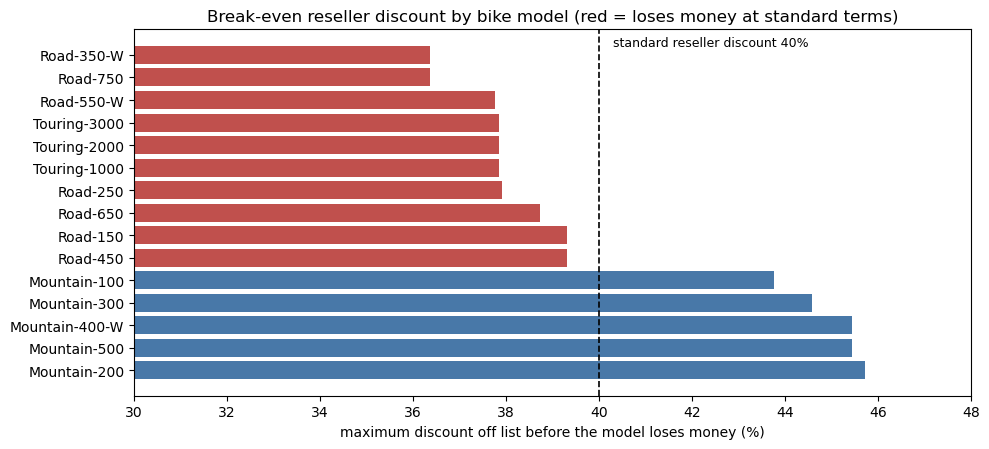

In [5]:
# === 4. Break-even discount by bike model ===
STD_DISC = 0.40
bikes = s[s["Category"] == "Bikes"]
# cost/list per model, weighted by the units actually sold (models have several product versions)
bk = bikes.groupby("Model").agg(cost_to_list=("Total Product Cost", "sum"), L=("L", "sum"))
bk["cost/list"] = bk["cost_to_list"] / bk["L"]
bk["break-even discount"] = 1 - bk["cost/list"]
rb_ltm = ltm[(ltm["Channel"] == "Reseller") & (ltm["Category"] == "Bikes")]
bk = (bk[["cost/list", "break-even discount"]]
      .join(rb_ltm.groupby("Model").agg(LTM_rev=("Sales Amount", "sum"), LTM_GP=("GP", "sum")))
      .sort_values("cost/list"))
print(bk.round(3).to_string(float_format=lambda v: f"{v:,.3f}"))

# classification at product-version level: does this version lose money at 60% of list?
prod = wb["Product_data"]; pb = prod[prod["Category"] == "Bikes"].copy()
pb["cost/list"] = pb["Standard Cost"] / pb["List Price"]
pb["family"] = pb["Model"].str.split("-").str[0]
print("\ncost/list range of product versions by family:")
print(pb.groupby("family")["cost/list"].agg(["min", "max", "size"]).round(3))
s["loss_at_std"] = s["Standard Cost"] / s["List Price"] > 1 - STD_DISC

# how much of reseller bike revenue comes from loss-making versions, by fiscal year
rb = s[(s["Channel"] == "Reseller") & (s["Category"] == "Bikes")]
share = rb.groupby("FY").apply(lambda d: d.loc[d["loss_at_std"], "Sales Amount"].sum()
                               / d["Sales Amount"].sum(), include_groups=False)
gp_fy = rb.groupby("FY")["GP"].sum() / 1e6
print("\nreseller bikes: revenue share of versions that lose money at standard terms, and gross profit ($M)")
print(pd.DataFrame({"loss-model share": share.round(3), "GP $M": gp_fy.round(2)}))
new_lines = sorted(set(rb_ltm["Model"]) - set(rb[rb["period"] == "prior"]["Model"]))
print(f"\nmodels first sold through resellers in the LTM: {new_lines}")

fig, ax = plt.subplots(figsize=(10, 4.6))
cols = [RED if v < STD_DISC else BLUE for v in bk["break-even discount"]]
ax.barh(bk.index, bk["break-even discount"] * 100, color=cols)
ax.axvline(STD_DISC * 100, color="k", ls="--", lw=1.2)
ax.text(STD_DISC * 100 + 0.3, len(bk) - 0.6, "standard reseller discount 40%", fontsize=9)
ax.set_xlim(30, 48); ax.set_xlabel("maximum discount off list before the model loses money (%)")
ax.set_title("Break-even reseller discount by bike model (red = loses money at standard terms)")
plt.tight_layout(); savefig("13_breakeven_discount.png"); plt.show()

**Road and Touring bikes lose money at standard reseller terms; Mountain bikes make
money.** Every Mountain version has a cost-to-list ratio of 54–56% (break-even discount
44–46%). Road and Touring versions sit at 60.5–63.6% (break-even 36–39.5%) — the only
exception is one Road-650 version at 59.1%. In the data, 94.6% of reseller order lines
are priced at exactly 60% of list — in effect one 40% discount, which cannot fit both families.

The problem is getting larger because the product line is moving towards the loss-making
versions: their share of reseller bike revenue went from **28% (FY2018) to 59% (FY2019) to
70% (FY2020)**. The entire Touring line plus Road-350-W and Road-750 entered the reseller channel
during the LTM, each below break-even from its first reseller sale (they went on sale online
on 31 May 2019 and reached resellers in early July; the two Mountain models that entered at
the same time are profitable). This is the mechanism behind the −$1.33M
mix effect in Section 3.

## 5. Root cause 2 — discounts on top of the standard reseller price

Beyond the standard 60%-of-list price, some reseller lines carry further discounts. Two
patterns are visible in the data: **volume tiers** (realised price 45–57% of list, on large
order lines averaging 14 units versus 3 at the standard price) and **deep discounts**
(12–38% of list, on small lines averaging 3–4 units — the profile of clearance or
promotional pricing). The two names are labels based on order-size patterns; the data has
no field recording the type of discount.

reseller price tiers, all history ($M):
                        lines  avg_qty  revenue     GP  rev share
tier                                                             
standard (60% of list)  57573    3.136   75.028  2.296      0.933
volume tier (45-57%)     2094   14.130    4.060 -0.193      0.050
deep discount (12-38%)   1188    3.561    1.362 -1.632      0.017



reseller price tiers, LTM ($M):
                        lines  avg_qty  revenue     GP  rev share
tier                                                             
standard (60% of list)  29074    3.181   33.377  0.438      0.902
volume tier (45-57%)     1362   14.620    2.554 -0.151      0.069
deep discount (12-38%)    989    3.464    1.061 -0.917      0.029



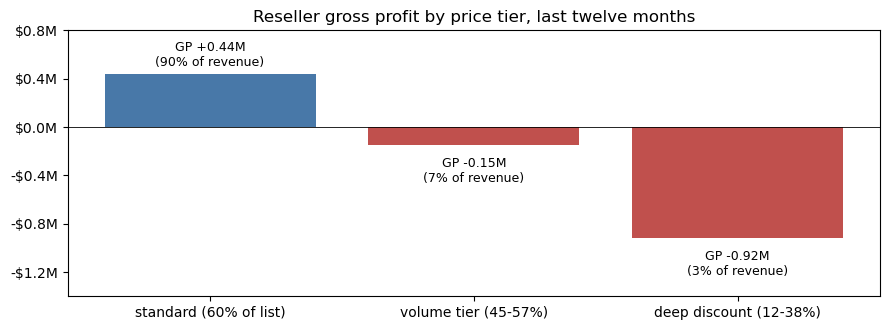

In [6]:
# === 5. Profitability of reseller price tiers ===
rs = s[s["Channel"] == "Reseller"].copy()
rs["price/list"] = (rs["Sales Amount"] / rs["L"]).round(2)
rs["tier"] = np.select([rs["price/list"] >= 0.595, rs["price/list"] >= 0.44],
                       ["standard (60% of list)", "volume tier (45-57%)"], "deep discount (12-38%)")
tiers = ["standard (60% of list)", "volume tier (45-57%)", "deep discount (12-38%)"]

def tier_table(d):
    t = d.groupby("tier").agg(lines=("GP", "size"), avg_qty=("Order Quantity", "mean"),
                              revenue=("Sales Amount", "sum"), GP=("GP", "sum")).reindex(tiers)
    t["rev share"] = t["revenue"] / t["revenue"].sum()
    return t

for name, d in [("all history", rs), ("LTM", rs[rs["period"] == "LTM"])]:
    t = tier_table(d); t[["revenue", "GP"]] /= 1e6
    print(f"reseller price tiers, {name} ($M):"); print(t.round(3)); print()

t_ltm = tier_table(rs[rs["period"] == "LTM"])
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(range(3), t_ltm["GP"] / 1e6, color=[BLUE if v >= 0 else RED for v in t_ltm["GP"]])
for i, (g, sh) in enumerate(zip(t_ltm["GP"], t_ltm["rev share"])):
    ax.text(i, g / 1e6 + (0.04 if g >= 0 else -0.1), f"GP {g/1e6:+.2f}M\n({sh:.0%} of revenue)",
            ha="center", va="bottom" if g >= 0 else "top", fontsize=9)
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(range(3), tiers); ax.set_ylim(-1.4, 0.8)
ax.set_yticks(np.arange(-1.2, 0.81, 0.4))
ax.yaxis.set_major_formatter(musd)
ax.set_title("Reseller gross profit by price tier, last twelve months")
plt.tight_layout(); savefig("14_discount_tiers.png"); plt.show()

**Extra discounts turn a thin profit into a loss.** In the LTM the standard-priced reseller
business earns only **+$0.44M** (1.3% margin on $33M), and the extra discounts — **10% of
reseller revenue** — lose **$1.07M**. Over the full history the pattern is the same: 7% of
reseller revenue at extra discount wiped out about 80% of the channel's standard-priced
gross profit.

Whether these discounts are a mistake depends on what they are for (clearing old stock,
winning a large account, launching a model) — which the data cannot tell. What the data
*can* say is that they are granted **below cost**, so they need a floor and an approval rule.

## 6. Action scenarios — what would a reseller price floor be worth?

Proposed policy: **no reseller line may be priced below standard cost ÷ (1 − target
margin)**. It covers both root causes at once — loss-making models get a model-specific
reseller price, and extra discounts cannot go below the floor.

Two things are uncertain, so both are shown as ranges rather than single numbers:

- **Volume retention** — how many affected units resellers still buy at the higher price
  (price elasticity is unknown; 100% / 80% / 60% shown).
- **Fixed share of standard cost** — if standard cost includes allocated fixed overhead,
  units that are lost do not save their full cost, and the profit gain shrinks. This is the
  difference between *gross margin* and *contribution margin*.

In [7]:
# === 6. Price-floor scenarios on the LTM reseller book ===
lr = ltm[ltm["Channel"] == "Reseller"].copy()
lr["unit_price"] = lr["Sales Amount"] / lr["Order Quantity"]
lr["unit_cost"] = lr["Product Standard Cost"]
R_LTM, GP_LTM = ltm["Sales Amount"].sum(), ltm["GP"].sum()

def floor_scenario(target_margin, retention, fixed_share=0.0):
    floor = lr["unit_cost"] / (1 - target_margin)
    a = lr[lr["unit_price"] < floor - 1e-9]; f = floor[a.index]; q = a["Order Quantity"]
    d_rev = (retention * q * f - a["Sales Amount"]).sum()
    d_gp = (retention * q * (f - a["unit_cost"]) - a["GP"]).sum()
    d_gp -= ((1 - retention) * q * a["unit_cost"] * fixed_share).sum()   # unabsorbed fixed cost
    return a, d_rev, d_gp

rows = []
for m in [0.0, 0.05]:
    for v in [1.0, 0.8, 0.6]:
        a, d_rev, d_gp = floor_scenario(m, v)
        rows.append([f"{m:.0%}", f"{v:.0%}", a["Sales Amount"].sum() / 1e6, d_rev / 1e6, d_gp / 1e6,
                     GP_LTM / R_LTM, (GP_LTM + d_gp) / (R_LTM + d_rev)])
sc = pd.DataFrame(rows, columns=["floor margin", "volume kept", "affected rev $M", "d revenue $M",
                                 "d GP $M", "company GM before", "company GM after"])
print(sc.round(3).to_string(index=False))

a0, _, _ = floor_scenario(0.0, 1.0)
print(f"\nlines below cost in the LTM: {len(a0):,} lines, ${a0['Sales Amount'].sum()/1e6:.2f}M revenue "
      f"({a0['Sales Amount'].sum()/lr['Sales Amount'].sum():.0%} of reseller revenue), GP ${a0['GP'].sum()/1e6:+.2f}M")

# sensitivity of the break-even floor to the fixed share of standard cost
fs = pd.DataFrame({f"fixed {f:.0%}": [floor_scenario(0.0, v, f)[2] / 1e6 for v in [1.0, 0.8, 0.6]]
                   for f in [0.0, 0.2, 0.4]}, index=["kept 100%", "kept 80%", "kept 60%"])
print("\nd GP ($M) of the break-even floor, by volume kept and fixed share of standard cost:")
print(fs.round(2))

floor margin volume kept  affected rev $M  d revenue $M  d GP $M  company GM before  company GM after
          0%        100%           22.468         2.155    2.155              0.113             0.148
          0%         80%           22.468        -2.770    2.155              0.113             0.163
          0%         60%           22.468        -7.694    2.155              0.113             0.180
          5%        100%           24.461         3.536    3.536              0.113             0.169
          5%         80%           24.461        -2.063    3.256              0.113             0.182
          5%         60%           24.461        -7.663    2.976              0.113             0.198

lines below cost in the LTM: 12,536 lines, $22.47M revenue (61% of reseller revenue), GP $-2.16M

d GP ($M) of the break-even floor, by volume kept and fixed share of standard cost:
           fixed 0%  fixed 20%  fixed 40%
kept 100%      2.16       2.16       2.16
kept 80%       2.16

**What the numbers say.**

- **61% of LTM reseller revenue ($22.5M) is sold below standard cost**, losing $2.2M in total.
  A break-even floor recovers that **+$2.2M** of gross profit (company gross profit
  $6.0M → $8.2M) whether or not resellers keep buying — at a zero-margin floor, a lost unit
  neither earns nor loses anything.
- The **price of the policy is revenue**: if 20% of affected volume is lost, revenue falls
  by $2.8M. A plan judged on revenue growth would reject this; a plan judged on profit would
  adopt it. Making that trade-off explicit is the point of the analysis.
- The gain is only safe if the standard cost is mostly **variable**. If 20% of it were
  allocated fixed overhead and 40% of the affected volume left, the gain would shrink to
  about $0.2M; at 40% fixed overhead it would turn into a $1.8M loss (see table).
  Confirming the cost structure with the cost-accounting team comes **before** the price
  change.

### 6b. Initiative bridge — which step first?

One policy is easier to approve, sequence and own when it is split into separate
initiatives. The floor is applied in three steps, each measured **on top of** the previous
one so nothing is counted twice (base case: 80% of affected volume kept; a line loses 20%
of its volume once, the first time its price is raised):

1. **Discount approval** — extra-discount lines (volume tiers and deep discounts) may not go
   below standard cost without sign-off
2. **Model-specific reseller prices** — standard-priced lines of loss-making versions are
   lifted to break-even
3. **Minimum margin** — the floor for all reseller lines is raised from break-even to a 5% margin

The same logic produces a **current → target** view of the KPIs that would track the plan.

                   step  revenue $M  GP $M  company GM  reseller GM  d revenue $M  d GP $M
          current (LTM)      53.025  6.012       0.113       -0.017           NaN      NaN
    1 discount approval      53.413  7.202       0.135        0.015         0.388    1.190
2 model-specific prices      50.255  8.167       0.163        0.045        -3.158    0.965
    3 minimum 5% margin      50.961  9.268       0.182        0.075         0.706    1.101

                                     current (LTM)  target (after steps 1-3)
company gross profit ($M)                   6.012                     9.268
company gross margin                        0.113                     0.182
reseller gross margin                      -0.017                     0.075
reseller revenue priced below cost          0.607                     0.000
GP of extra-discount lines ($M)            -1.068                     0.292
Road/Touring reseller bike GM              -0.093                     0.050


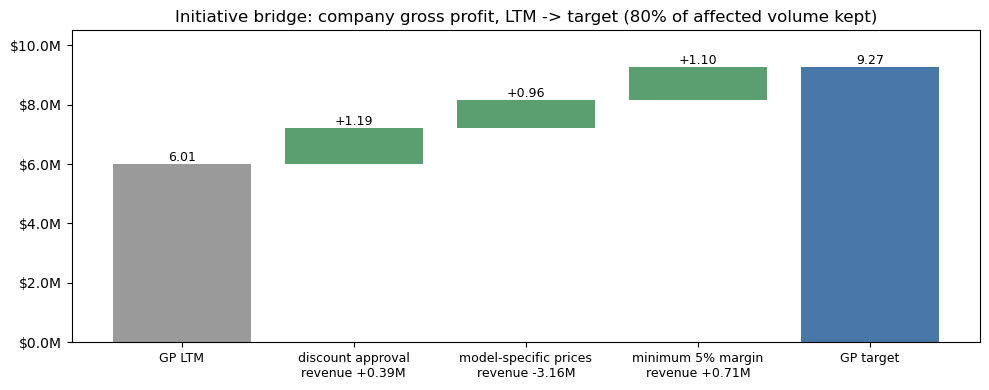

In [8]:
# === 6b. Initiative bridge and current -> target KPIs (80% of affected volume kept) ===
V_KEEP = 0.8
book = lr[["unit_price", "unit_cost", "Order Quantity", "Sales Amount", "L"]].copy()
book["extra_discount"] = book["Sales Amount"] / book["L"] < 0.595      # below the standard 60% of list
book["price"] = book["unit_price"]
book["qty"] = book["Order Quantity"].astype(float)
book["raised"] = False

def apply_floor(b, margin, mask):
    b = b.copy()
    floor = b["unit_cost"] / (1 - margin)
    hit = mask & (b["price"] < floor - 1e-9)
    b.loc[hit, "price"] = floor[hit]
    first = hit & ~b["raised"]
    b.loc[first, "qty"] *= V_KEEP                  # volume is lost once, at the first price rise
    b["raised"] |= hit
    return b

def totals(b):
    return (b["qty"] * b["price"]).sum(), (b["qty"] * (b["price"] - b["unit_cost"])).sum()

internet = ltm[ltm["Channel"] == "Internet"]
R_INT, GP_INT = internet["Sales Amount"].sum(), internet["GP"].sum()
steps_book = {"current (LTM)": book}
steps_book["1 discount approval"] = apply_floor(book, 0.0, book["extra_discount"])
steps_book["2 model-specific prices"] = apply_floor(steps_book["1 discount approval"], 0.0, ~book["extra_discount"])
steps_book["3 minimum 5% margin"] = apply_floor(steps_book["2 model-specific prices"], 0.05,
                                            pd.Series(True, index=book.index))

rows, prev = [], None
for name, b in steps_book.items():
    r_res, gp_res = totals(b)
    rev, gp = R_INT + r_res, GP_INT + gp_res
    rows.append([name, rev / 1e6, gp / 1e6, gp / rev, gp_res / r_res,
                 None if prev is None else (rev - prev[0]) / 1e6, None if prev is None else (gp - prev[1]) / 1e6])
    prev = (rev, gp)
ib = pd.DataFrame(rows, columns=["step", "revenue $M", "GP $M", "company GM", "reseller GM", "d revenue $M", "d GP $M"])
print(ib.round(3).to_string(index=False))

# consistency with the Section 6 scenarios
assert np.isclose(ib["GP $M"].iloc[2] * 1e6 - GP_LTM, floor_scenario(0.0, V_KEEP)[2])
assert np.isclose(ib["GP $M"].iloc[3] * 1e6 - GP_LTM, floor_scenario(0.05, V_KEEP)[2])

# current -> target KPIs
cur, tgt = steps_book["current (LTM)"], steps_book["3 minimum 5% margin"]
def kpis(b):
    r_res, gp_res = totals(b)
    rev_line = b["qty"] * b["price"]; gp_line = b["qty"] * (b["price"] - b["unit_cost"])
    return {"company gross profit ($M)": (GP_INT + gp_res) / 1e6,
            "company gross margin": (GP_INT + gp_res) / (R_INT + r_res),
            "reseller gross margin": gp_res / r_res,
            "reseller revenue priced below cost": rev_line[b["price"] < b["unit_cost"] - 1e-9].sum() / r_res,
            "GP of extra-discount lines ($M)": gp_line[b["extra_discount"]].sum() / 1e6,
            "Road/Touring reseller bike GM": None}
k_cur, k_tgt = kpis(cur), kpis(tgt)
rt = lr["Model"].str.match(r"^(Road|Touring)-") & (lr["Category"] == "Bikes")
for k, b in [(k_cur, cur), (k_tgt, tgt)]:
    bb = b[rt.values]
    k["Road/Touring reseller bike GM"] = (bb["qty"] * (bb["price"] - bb["unit_cost"])).sum() / (bb["qty"] * bb["price"]).sum()
kpi = pd.DataFrame({"current (LTM)": k_cur, "target (after steps 1-3)": k_tgt})
print("\n", kpi.round(3))

# waterfall: gross profit from current to target, revenue effect under each step
fig, ax = plt.subplots(figsize=(10, 4))
gps = ib["GP $M"].values; dgp = ib["d GP $M"].values; drev = ib["d revenue $M"].values
labels = ["GP LTM"] + [f"{n[2:]}\nrevenue {d:+.2f}M" for n, d in zip(ib["step"][1:], drev[1:])] + ["GP target"]
ax.bar(0, gps[0], color=GREY); ax.text(0, gps[0] + 0.1, f"{gps[0]:.2f}", ha="center", fontsize=9)
for i in range(1, 4):
    ax.bar(i, dgp[i], bottom=gps[i - 1], color=GREEN)
    ax.text(i, gps[i] + 0.1, f"+{dgp[i]:.2f}", ha="center", fontsize=9)
ax.bar(4, gps[3], color=BLUE); ax.text(4, gps[3] + 0.1, f"{gps[3]:.2f}", ha="center", fontsize=9)
ax.set_xticks(range(5), labels, fontsize=9); ax.yaxis.set_major_formatter(musd); ax.set_ylim(0, 10.5)
ax.set_title("Initiative bridge: company gross profit, LTM -> target (80% of affected volume kept)")
plt.tight_layout(); savefig("16_initiative_bridge.png"); plt.show()

**Splitting the policy changes the order of execution.**

- **Step 1, discount approval, is the cheapest win**: +$1.19M gross profit while revenue
  even rises slightly (+$0.39M), because the lines affected were priced far below cost.
  It is also the easiest to implement — an approval rule, not a price-list change.
- **Step 2 is the one that costs revenue**: +$0.96M gross profit for −$3.16M revenue. This is
  the step that needs the sales conversation (Section 8, questions 1 and 2) before it starts.
- **Step 3** adds a further +$1.10M by moving the floor from break-even to a 5% margin.
- Together: gross profit **$6.01M → $9.27M**, company gross margin **11.3% → 18.2%**,
  reseller gross margin **−1.7% → 7.5%**, on revenue about $2.1M (4%) lower.

One caveat specific to step 1: for **clearance stock** the standard cost is already sunk —
if the alternative is writing the stock off, selling below standard cost can be the right
decision. That is why step 1 is an *approval* rule with stated reasons, not a ban, and why
its gain is an upper bound.

## 7. Next-year operating simulation — status quo vs initiatives

Sections 6 and 6b measure the initiatives on the **last twelve months**. Management plans
for the **next** twelve, where three things are uncertain at once. The simulation combines
them in one Monte Carlo (10,000 trials):

| Uncertainty | How it is simulated | Source |
|---|---|---|
| Revenue growth | growth ~ N(43.2%, 8.8%), seed 42 | Part 1 Monte Carlo, reproduced exactly |
| Seasonality and product / channel mix | each trial resamples 365 LTM days within their calendar month; every drawn day carries its full order book (channel, model, price, cost) | Part 1 month-stratified bootstrap design, seed 7 |
| Execution of the initiatives | share of volume kept on repriced lines, **by order type** (see below); fixed share of standard cost ~ Uniform(0%, 30%) | **assumptions** — no elasticity or cost-structure data exist |

Two scenarios are compared on the **same** simulated years: **without initiatives** (status
quo) and **with all three initiatives** of Section 6b. Because both run on identical growth and
mix draws, the difference between them in each trial isolates the effect of the initiatives.
Unit costs are not changed by any initiative: these are *pricing* measures.

**Volume kept, by order type.** The price rise is very different across the repriced lines,
so one retention assumption for all of them would be unrealistic (Section 6b uses a single 80%
only as a simple illustration):

| Order type | Share of repriced revenue | Average price rise | Volume kept (assumption) | Implied price elasticity |
|---|---|---|---|---|
| Standard price (mostly Road / Touring bikes) | 87% | +10% | Triangular(60%, 80%, 100%) | about −2 at the mode |
| Volume tier | 9% | +18% | Triangular(40%, 60%, 80%) | about −2.3 at the mode |
| Deep discount (clearance profile) | 4% | +96% | Uniform(0%, 30%) | most volume disappears |

For reference, meta-analyses of consumer-goods brands put the average price elasticity at
roughly −2 to −2.6; resellers may react less (contracts, switching costs, pass-through to
consumers) or more (competing brands offering better dealer margins). These are judgments to be
replaced by a regional pilot, not estimates — the retention sensitivity table below shows where
the conclusion breaks.

repriced reseller lines by order type (LTM):
               share of repriced revenue  average price rise
standard                           0.867               0.100
volume tier                        0.090               0.175
deep discount                      0.043               0.962



next twelve months -- median [5th, 95th percentile]; changes are paired, trial by trial:
               without initiatives        with all three                      change             change %
revenue $M    75.85 [67.53, 84.39]  70.17 [61.39, 79.26]       -5.67 [-10.33, -1.08]      -7% [-14%, -1%]
COGS $M       67.27 [59.68, 75.10]  58.60 [50.93, 66.43]       -8.54 [-13.07, -4.76]     -13% [-19%, -7%]
GP $M            8.60 [7.64, 9.57]   11.64 [9.37, 13.65]        +3.11 [+1.02, +4.56]    +36% [+12%, +53%]
gross margin  11.3% [10.5%, 12.2%]  16.5% [14.2%, 18.7%]  +5.2 pp [+2.9 pp, +7.3 pp]    +46% [+26%, +66%]
reseller GM   -1.7% [-2.3%, -1.1%]     4.7% [0.3%, 7.3%]  +6.4 pp [+2.0 pp, +9.1 pp]  n/a (negative base)

P(gross profit higher with initiatives) = 99.59%
P(gross margin higher with initiatives) = 100.00%
revenue growth vs LTM ($53.0M): without +43%, with +32%

retention sensitivity (other order types and fixed share still random):
                         median d GP $M 5th pc

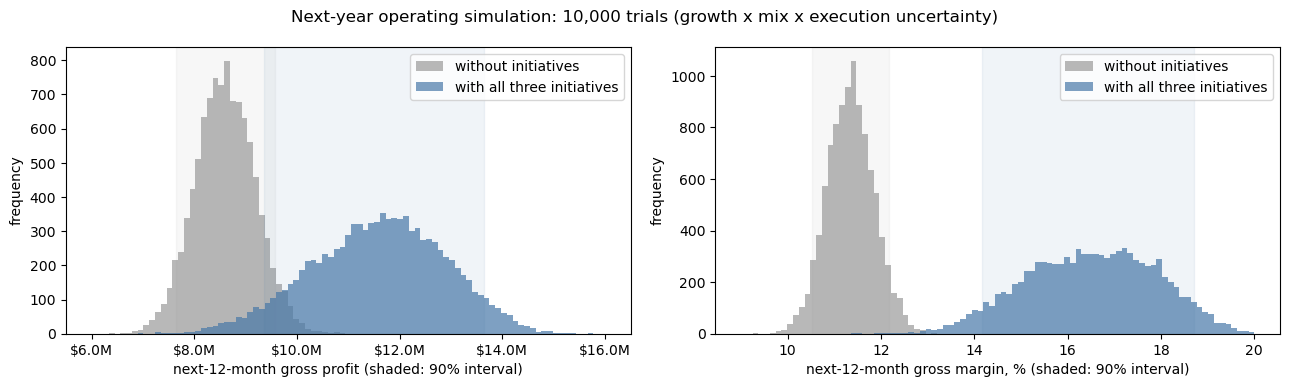

In [9]:
# === 7. Next-year operating simulation (10,000 trials) ===
N = 10_000
# (a) growth: reproduce Part 1 exactly (TTM YoY distribution, seed 42)
daily = s.groupby("date")["Sales Amount"].sum().sort_index()
monthly_complete = daily.resample("MS").sum().loc[:"2020-05-01"]
yoy_ttm = monthly_complete.rolling(12).sum().dropna().pct_change(12).dropna()
mu, sigma = yoy_ttm.mean(), yoy_ttm.std(ddof=1)
growth = np.random.default_rng(42).normal(mu, sigma, N)

# (b) day-level building blocks of the LTM book; every initiative is linear in v (volume kept)
#     and fx (fixed share of standard cost), so each day only needs three sums per initiative
q, c = ltm["Order Quantity"], ltm["Product Standard Cost"]
p = ltm["Sales Amount"] / q
is_res = ltm["Channel"] == "Reseller"
extra_disc = ltm["Sales Amount"] / ltm["L"] < 0.595

# all three initiatives combined = a 5%-margin floor on every reseller line (identical to Section 6b, step 3)
floor5 = c / 0.95
repriced = is_res & (p < floor5 - 1e-9)
pl_ = ltm["Sales Amount"] / ltm["L"]
order_type = pd.Series(np.select([pl_ >= 0.595, pl_ >= 0.44], ["standard", "volume tier"], "deep discount"),
                       index=ltm.index)
TYPES = ["standard", "volume tier", "deep discount"]

cols = {"rev": ltm["Sales Amount"], "cogs": ltm["Total Product Cost"],
        "res_rev": ltm["Sales Amount"].where(is_res, 0.0), "res_cogs": ltm["Total Product Cost"].where(is_res, 0.0)}
for t_ in TYPES:
    a = repriced & (order_type == t_)
    cols[f"{t_}|qF"] = (q * floor5).where(a, 0.0)
    cols[f"{t_}|sales"] = ltm["Sales Amount"].where(a, 0.0)
    cols[f"{t_}|qc"] = (q * c).where(a, 0.0)

# price rise and weight of each order type among repriced lines (LTM)
pr_ = pd.DataFrame({t_: {"share of repriced revenue": cols[f"{t_}|sales"].sum(),
                         "average price rise": cols[f"{t_}|qF"].sum() / cols[f"{t_}|sales"].sum() - 1} for t_ in TYPES}).T
pr_["share of repriced revenue"] /= pr_["share of repriced revenue"].sum()
print("repriced reseller lines by order type (LTM):"); print(pr_.round(3)); print()
# consistency with Section 6: at 80% kept everywhere and no fixed cost, the LTM effect equals floor_scenario(5%, 80%)
assert np.isclose(sum((0.8 * cols[f"{t_}|qF"] - cols[f"{t_}|sales"]).sum() for t_ in TYPES), floor_scenario(0.05, 0.8)[1])
day = pd.DataFrame(cols).groupby(ltm["date"]).sum()
assert len(day) == 365

# (c) month-stratified bootstrap of LTM days (Part 1 design): each drawn day carries its full order book
rng_b = np.random.default_rng(7)
months = day.index.month.values
draw = np.empty((N, len(day)), dtype=np.int32)
for m in range(1, 13):
    pos = np.where(months == m)[0]
    draw[:, pos] = rng_b.choice(pos, size=(N, len(pos)), replace=True)
T = pd.DataFrame({col: day[col].values[draw].sum(axis=1) for col in day.columns})

# (d) execution uncertainty -- assumptions, not data
KEEP = {"standard": np.random.default_rng(11).triangular(0.6, 0.8, 1.0, N),        # share of volume kept
        "volume tier": np.random.default_rng(13).triangular(0.4, 0.6, 0.8, N),
        "deep discount": np.random.default_rng(14).uniform(0.0, 0.3, N)}
fx = np.random.default_rng(12).uniform(0.0, 0.3, N)                                 # fixed share of standard cost

def simulate(initiatives=False, keep=KEEP, fx=fx):
    d_rev = d_gp = 0.0
    if initiatives:
        for t_ in TYPES:
            v_ = keep[t_]
            qF, sales, qc = T[f"{t_}|qF"], T[f"{t_}|sales"], T[f"{t_}|qc"]
            d_rev = d_rev + v_ * qF - sales
            d_gp = d_gp + v_ * (qF - qc) - (sales - qc) - (1 - v_) * fx * qc   # lost units keep their fixed cost
    k = 1 + growth
    rev, gp = k * (T["rev"] + d_rev), k * (T["rev"] - T["cogs"] + d_gp)
    res_rev, res_gp = k * (T["res_rev"] + d_rev), k * (T["res_rev"] - T["res_cogs"] + d_gp)
    return pd.DataFrame({"revenue $M": rev / 1e6, "COGS $M": (rev - gp) / 1e6, "GP $M": gp / 1e6,
                         "gross margin": gp / rev, "reseller GM": res_gp / res_rev})

without, with_ = simulate(), simulate(initiatives=True)

def band(x, unit):
    f = {"$M": "{:.2f}", "%": "{:.1%}", "pp": "{:+.1f} pp", "d$M": "{:+.2f}", "d%": "{:+.0%}"}[unit]
    return f"{f.format(x.median())} [{f.format(x.quantile(.05))}, {f.format(x.quantile(.95))}]"

rows = {}
for col, unit in [("revenue $M", "$M"), ("COGS $M", "$M"), ("GP $M", "$M")]:
    a, b = without[col], with_[col]
    rows[col] = {"without initiatives": band(a, unit), "with all three": band(b, unit),
                 "change": band(b - a, "d$M"), "change %": band(b / a - 1, "d%")}
for col in ["gross margin", "reseller GM"]:
    a, b = without[col], with_[col]
    rows[col] = {"without initiatives": band(a, "%"), "with all three": band(b, "%"),
                 "change": band((b - a) * 100, "pp"),
                 "change %": band(b / a - 1, "d%") if (a > 0).all() else "n/a (negative base)"}
cmp7 = pd.DataFrame(rows).T
print("next twelve months -- median [5th, 95th percentile]; changes are paired, trial by trial:")
print(cmp7.to_string())
print(f"\nP(gross profit higher with initiatives) = {(with_['GP $M'] > without['GP $M']).mean():.2%}")
print(f"P(gross margin higher with initiatives) = {(with_['gross margin'] > without['gross margin']).mean():.2%}")
print(f"revenue growth vs LTM (${R_LTM/1e6:.1f}M): without {(without['revenue $M'] * 1e6 / R_LTM - 1).median():+.0%}, "
      f"with {(with_['revenue $M'] * 1e6 / R_LTM - 1).median():+.0%}")

# where does the conclusion break? fix the retention of standard-price lines (87% of repriced revenue)
sens = {}
for v_ in [1.0, 0.8, 0.6, 0.4, 0.2]:
    w = simulate(initiatives=True, keep={**KEEP, "standard": np.full(N, v_)})
    d = w["GP $M"] - without["GP $M"]
    sens[f"standard lines keep {v_:.0%}"] = {"median d GP $M": round(d.median(), 2), "5th pct": round(d.quantile(.05), 2),
                                             "P(d GP > 0)": f"{(d > 0).mean():.1%}",
                                             "median d revenue": f"{(w['revenue $M'] / without['revenue $M'] - 1).median():+.1%}"}
print("\nretention sensitivity (other order types and fixed share still random):")
print(pd.DataFrame(sens).T.to_string())

# robustness: how much does the plan depend on the fixed-cost assumption?
rob = {}
for f_ in [0.0, 0.2, 0.4]:
    d = simulate(initiatives=True, fx=np.full(N, f_))["GP $M"] - without["GP $M"]
    rob[f"fixed share {f_:.0%}"] = {"median d GP $M": round(d.median(), 2), "5th pct": round(d.quantile(.05), 2),
                                    "P(d GP > 0)": f"{(d > 0).mean():.1%}"}
print("\nd GP vs fixed share of standard cost (volume kept still random):")
print(pd.DataFrame(rob).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
for name, d, col_ in [("without initiatives", without, GREY), ("with all three initiatives", with_, BLUE)]:
    for ax, series, bins in [(axes[0], d["GP $M"], np.linspace(6, 16, 90)),
                             (axes[1], d["gross margin"] * 100, np.linspace(9, 20, 90))]:
        ax.hist(series, bins=bins, color=col_, alpha=0.7, label=name)
        lo, hi = series.quantile([.05, .95])
        ax.axvspan(lo, hi, color=col_, alpha=0.08)
axes[0].xaxis.set_major_formatter(musd); axes[0].set_xlabel("next-12-month gross profit (shaded: 90% interval)")
axes[1].set_xlabel("next-12-month gross margin, % (shaded: 90% interval)")
for ax in axes:
    ax.set_ylabel("frequency"); ax.legend(loc="upper right")
fig.suptitle("Next-year operating simulation: 10,000 trials (growth x mix x execution uncertainty)")
plt.tight_layout(); savefig("15_profit_forecast.png"); plt.show()

**What the simulation says about next year** (median, 90% interval in brackets):

- **Without initiatives**: revenue $75.9M (+43% on the LTM), gross profit $8.6M [$7.6M, $9.6M]
  at a **11.3%** gross margin [10.5%, 12.2%]; the reseller channel stays loss-making (−1.7%).
- **With all three initiatives**: revenue $70.2M (still +32% on the LTM), gross profit
  **$11.6M** [$9.4M, $13.7M] at a **16.5%** gross margin [14.2%, 18.7%]; reseller margin
  turns positive (4.7%).
- **Improvement, measured trial by trial on the same simulated year**: gross margin
  **+5.2 percentage points** [+2.9, +7.3] (relative +46%); gross profit **+$3.1M**, about
  **+36%** [+12%, +53%]; revenue about −7% versus the no-initiative case — about two-thirds
  of it from standard-price Road/Touring lines losing volume after a 10% price rise. Gross profit is higher in 99.6% of trials,
  gross margin in all of them.
- **The gross-margin intervals do not overlap**: the pessimistic end with initiatives (5th
  percentile, 14.2%) is above the optimistic end without them (95th percentile, 12.2%). The
  gross-profit intervals overlap slightly ($9.4M vs $9.6M).
- **COGS falls, but this is not a cost saving**: unit costs are unchanged; COGS falls only
  because fewer units are sold. The improvement is entirely a **pricing** effect.
- **Where the conclusion breaks** (sensitivity tables): if standard-price lines keep only 60%
  of their volume, the gain is still +$1.7M at the median but positive in 85% of trials; at 40%
  it is a coin toss. If 40% of standard cost is fixed, the median gain shrinks to +$0.4M and
  about a third of trials lose money. Hence the order in Section 8: confirm the cost structure,
  then pilot the price change in one region before rolling it out.

These are **projections under stated assumptions**, not realised results. Mix is frozen at
the LTM pattern, so if the shift towards loss-making models continues (Section 4), the status
quo would be worse than shown and the value of the plan larger.

## 8. Findings → actions

| # | Finding | Root cause | Recommendation | Quantified impact (LTM basis, 80% of affected volume kept) | Owner | KPI: current → target |
|---|---|---|---|---|---|---|
| 1 | Extra discounts: 10% of reseller revenue, −$1.07M GP | Volume tiers and deep discounts granted below cost | **Start here.** Floor at standard cost; any line below it needs sign-off with a stated reason (clearance, launch, strategic account) | +$1.19M GP, revenue +$0.39M | Sales ops + Finance | GP of extra-discount lines: −$1.07M → +$0.29M |
| 2 | Reseller revenue +34%, reseller GP +$0.76M → −$0.63M | Product mix towards Road/Touring (−$1.33M in the bridge) | Model-specific reseller prices for Road/Touring at break-even, replacing the uniform 40% discount; then raise the floor to a 5% margin for all reseller lines | +$0.96M GP for −$3.16M revenue at break-even; a further +$1.10M GP at the 5% floor | Pricing + Sales | Reseller GM: −1.7% → 7.5%; Road/Touring reseller bike GM: −9.3% → 5.0% |
| 3 | New Touring line is below break-even in the reseller channel from launch | Suspected: prices set without a channel-margin check (not provable from the data; to confirm with Product) | Add a channel-margin check to the launch process: every new model priced so each channel clears the minimum margin | Prevents repeating the $1.24M LTM loss of the Touring launch | Product + Finance | Channel margin of new models in first two quarters ≥ 5% |
| 4 | Internet: ~30% of revenue, >100% of company GP | Sells at list price | Prioritise Internet growth for profitable families — **after** loading Internet with fulfilment and marketing costs, which gross margin excludes | Not quantifiable without opex data | Marketing + Finance | Internet contribution margin per order (to be built) |

Company level, current → target after steps 1–3 (Section 6b): gross profit $6.01M → $9.27M,
gross margin 11.3% → 18.2%, share of reseller revenue priced below cost 61% → 0%.

### Questions finance cannot answer alone

The analysis can show *where* margin is lost; whether a recommendation is right depends on
facts only the business holds:

1. **Sales** — Is the 40% reseller discount contractual, a rebate structure, or a response to
   competitors? How many resellers would leave at a model-specific price?
2. **Product** — Was the Touring line deliberately priced below cost to win share at launch?
   If so, what is the planned path to a positive margin?
3. **Cost accounting** — How much of standard cost is allocated fixed overhead? (This
   decides whether "loss-making" lines are really losing money at the contribution level.)
4. **Sales ops** — What are the deep discounts (12–38% of list) for — clearing old stock,
   promotions, key accounts? Who approves them?
5. **Channel** — Would pushing Road/Touring through the Internet channel create conflict with
   resellers that matters for Mountain bike volume?

### Limitations

- Gross profit at **standard** cost; actual cost variances, freight, returns and operating
  expenses are not in the data. Internet's margin advantage is overstated at gross level.
- Price elasticity is unknown, hence the retention ranges instead of one number.
- Sample data from a teaching dataset: the mechanisms are realistic, the magnitudes are not
  benchmarks.
- Assumptions (volume lost, fixed share of cost, 5% target margin) and inferences (discount-type
  names, the suspected root cause of finding 3) are flagged where they appear; every other number
  is computed directly from the raw data.